In [1]:
import pandas as pd
import yfinance as yfn
import matplotlib.pyplot as plt

from datetime import date

Question 1: [Index] S&P 500 Stocks Added to the Index

Which year had the highest number of additions (starting from 2020)?

In [2]:
WP_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
UA = {"User-Agent": "Mozilla/5.0"}

#list of dfs from html
sp_tables = pd.read_html(WP_URL, storage_options=UA)
print("Tables found:", len(sp_tables))

Tables found: 2


In [3]:
#get first table
sp_tables[0]

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [4]:
sp_tables[1]

,vteS&P 500 companies,vteS&P 500 companies.1
0,Energy,APA Corporation Baker Hughes Chevron Corporati...
1,Materials,Air Products Albemarle Corporation Amcor Avery...
2,Industrials,3M A. O. Smith Allegion Ametek Automatic Data ...
3,Consumer discretionary,Airbnb Amazon Aptiv AutoZone Best Buy Booking ...
4,Consumer staples,Altria Archer Daniels Midland Brown-Forman Bun...
5,Health Care,Abbott Laboratories AbbVie Agilent Technologie...
6,Financials,Aflac Allstate American Express American Inter...
7,Information technology,Accenture Adobe Inc. Akamai Technologies AMD A...
8,Communication services,Alphabet Inc. AT&T Charter Communications Comc...
9,Real estate,Alexandria Real Estate Equities American Tower...


In [5]:
#get sp df from first table
sp_data = sp_tables[0]

In [6]:
#select desired clumns
sp_df = sp_data[["Symbol","Security","Date added"]]
sp_df.head()

,Symbol,Security,Date added
0,MMM,3M,1957-03-04
1,AOS,A. O. Smith,2017-07-26
2,ABT,Abbott Laboratories,1957-03-04
3,ABBV,AbbVie,2012-12-31
4,ACN,Accenture,2011-07-06


In [7]:
#get year from year_added
sp_df["year_added"] = pd.to_datetime(sp_df["Date added"]).dt.year

In [8]:
sp_df.head()

,Symbol,Security,Date added,year_added
0,MMM,3M,1957-03-04,1957
1,AOS,A. O. Smith,2017-07-26,2017
2,ABT,Abbott Laboratories,1957-03-04,1957
3,ABBV,AbbVie,2012-12-31,2012
4,ACN,Accenture,2011-07-06,2011


In [9]:
#highest additions starting 2020
high_adds_msk = sp_df["year_added"] >= 2020
high_adds_sp = sp_df[high_adds_msk]
high_adds_sp["year_added"].value_counts(ascending=False).index[0].item()

2025

How many current S&P 500 stocks have been in the index for more than 20 years?

In [10]:
#get current year
today = date.today()
year = today.year
#subtract year_added from current year for each index
sp_df["years_in"] = sp_df["year_added"].apply(lambda year_added : year - year_added)
#filter indexes with 20+ years
YRS_IN = 20
yrs_in_msk = sp_df["years_in"] > YRS_IN
yrs_in = sp_df[yrs_in_msk]
yrs_in.sort_values(by=["years_in"], ascending=False)

,Symbol,Security,Date added,year_added,years_in
0,MMM,3M,1957-03-04,1957,69
2,ABT,Abbott Laboratories,1957-03-04,1957,69
21,MO,Altria,1957-03-04,1957,69
25,AEP,American Electric Power,1957-03-04,1957,69
43,ADM,Archer Daniels Midland,1957-03-04,1957,69
...,...,...,...,...,...
30,AMP,Ameriprise Financial,2005-10-03,2005,21
122,STZ,Constellation Brands,2005-07-01,2005,21
284,LEN,Lennar,2005-10-04,2005,21
378,PSA,Public Storage,2005-08-19,2005,21


In [11]:
#number of indexes with 20+ yrs
yrs_in.shape[0]

218

Question 2. [Macro] Indexes YTD (as of 21 August 2026)
How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026?

Using Yahoo Finance World Indices data, compare the year-to-date (YTD) performance (1 January-21 August 2026, use the closing price to calculate the growth) of major stock market indexes for the following countries:

United States - S&P 500 (^GSPC) \
China - Shanghai Composite (000001.SS) \
Hong Kong - HANG SENG INDEX (^HSI) \
Australia - S&P/ASX 200 (^AXJO) \
India - Nifty 50 (^NSEI) \
Canada - S&P/TSX Composite (^GSPTSE) \
Germany - DAX (^GDAXI) \
United Kingdom - FTSE 100 (^FTSE) \
Japan - Nikkei 225 (^N225) \
Mexico - IPC Mexico (^MXX) \
Brazil - Ibovespa (^BVSP) \

Hint: use start_date='2026-01-01' and end_date='2026-08-21' parameters when downloading daily data in yfinance

In [12]:
TICKERS = [
    "^GSPC", #S&P 500
    "000001.SS", #China - Shanghai Composite
    "^HSI", #Hong Kong - HANG SENG INDEX
    "^AXJO", #Australia - S&P/ASX 200
    "^NSEI", #India - Nifty 50,
    "^GSPTSE", #Canada - S&P/TSX Composite
    "^GDAXI", #Germany - DAX
    "^FTSE", #United Kingdom - FTSE 100
    "^N225", #Japan - Nikkei 225
    "^MXX", #Mexico - IPC Mexico
    "^BVSP" #Brazil - Ibovespa
]

DATE_START = "2026-01-01"
DATE_END = "2026-08-22" #date is exclusive, add 1+ day of your target

ytd_data = yfn.download(
    TICKERS,
    start=DATE_START,
    end=DATE_END,
    progress=False
)

In [13]:
ytd_data.head()

Price             Close                                                     \
Ticker        000001.SS        ^AXJO     ^BVSP         ^FTSE        ^GDAXI   
Date                                                                         
2026-01-01          NaN          NaN       NaN           NaN           NaN   
2026-01-02          NaN  8727.799805  160539.0   9951.099609  24539.339844   
2026-01-05  4023.416992  8728.599609  161870.0  10004.599609  24868.689453   
2026-01-06  4083.666992  8714.599609  163664.0  10122.700195  24892.199219   
2026-01-07  4085.771973  8695.599609  161975.0  10048.200195  25122.259766   

Price                                                              \
Ticker            ^GSPC       ^GSPTSE          ^HSI          ^MXX   
Date                                                                
2026-01-01          NaN           NaN           NaN           NaN   
2026-01-02  6858.470215  31883.400391  26338.470703  64141.359375   
2026-01-05  6902.049805  32220.000000  26347.240234  65014.371094   
2026-01-06  6944.819824  32407.000000  26710.449219  65022.238281   
2026-01-07  6920.930176  32135.500000  26458.949219  64871.699219   

Price                     ...    Volume                                      \
Ticker             ^N225  ...     ^AXJO      ^BVSP        ^FTSE      ^GDAXI   
Date                      ...                                                 
2026-01-01           NaN  ...       NaN        NaN          NaN         NaN   
2026-01-02           NaN  ...  272200.0  7459400.0  627469100.0  48788700.0   
2026-01-05  51832.800781  ...  436300.0  7985200.0  713151500.0  53518200.0   
2026-01-06  52518.078125  ...   73400.0  8412600.0  718171700.0  57420800.0   
2026-01-07  51961.980469  ...  607400.0  8846600.0  705731900.0  57897000.0   

Price                                                                          \
Ticker             ^GSPC      ^GSPTSE          ^HSI         ^MXX        ^N225   
Date                                                                            
2026-01-01           NaN          NaN           NaN          NaN          NaN   
2026-01-02  4.184120e+09  219395600.0  1.489700e+09   44991600.0          NaN   
2026-01-05  5.771930e+09  375678700.0  3.692200e+09   89779700.0  139400000.0   
2026-01-06  5.509680e+09  336760000.0  3.800900e+09  190182900.0  151900000.0   
2026-01-07  5.214480e+09  344537700.0  3.645300e+09  126392600.0  138600000.0   

Price                 
Ticker         ^NSEI  
Date                  
2026-01-01  425600.0  
2026-01-02  357500.0  
2026-01-05  338800.0  
2026-01-06  383000.0  
2026-01-07  338200.0  

[5 rows x 55 columns]

In [14]:
#expoloring missing values
ytd_data["Close"].isnull().sum()

Ticker
000001.SS    13
^AXJO         5
^BVSP         7
^FTSE         5
^GDAXI        4
^GSPC         7
^GSPTSE       6
^HSI         11
^MXX          6
^N225        12
^NSEI        10
dtype: int64

In [15]:
#get close price data
ytd_data_close = ytd_data["Close"]
ytd_data_close.head()

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26146.550781
2026-01-02,NaN,8727.799805,160539.0,9951.099609,24539.339844,6858.470215,31883.400391,26338.470703,64141.359375,NaN,26328.550781
2026-01-05,4023.416992,8728.599609,161870.0,10004.599609,24868.689453,6902.049805,32220.000000,26347.240234,65014.371094,51832.800781,26250.300781
2026-01-06,4083.666992,8714.599609,163664.0,10122.700195,24892.199219,6944.819824,32407.000000,26710.449219,65022.238281,52518.078125,26178.699219
2026-01-07,4085.771973,8695.599609,161975.0,10048.200195,25122.259766,6920.930176,32135.500000,26458.949219,64871.699219,51961.980469,26140.750000


In [16]:
#use first price of first valid index of each column independently
indices = ytd_data_close.apply(lambda column : column.first_valid_index())
#use only diagonal values (value of first valid index)
values = ytd_data_close.apply(lambda column : column[column.first_valid_index()])
values

Ticker
000001.SS      4023.416992
^AXJO          8727.799805
^BVSP        160539.000000
^FTSE          9951.099609
^GDAXI        24539.339844
^GSPC          6858.470215
^GSPTSE       31883.400391
^HSI          26338.470703
^MXX          64141.359375
^N225         51832.800781
^NSEI         26146.550781
dtype: float64

In [17]:
#get year-to-date returns
ytd_performance = (ytd_data_close / values - 1) * 100
ytd_performance

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2026-01-02,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.696077
2026-01-05,0.000000,0.009164,0.829082,0.537629,1.342129,0.635413,1.055721,0.033296,1.361075,0.000000,0.396802
2026-01-06,1.497483,-0.151243,1.946568,1.724438,1.437933,1.259021,1.642233,1.412301,1.373340,1.322092,0.122955
2026-01-07,1.549802,-0.368938,0.894487,0.975777,2.375451,0.910698,0.790692,0.457424,1.138641,0.249224,-0.022186
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-17,-1.013142,3.957474,3.890020,7.729801,7.332184,12.926933,15.006235,-3.361016,0.177142,33.545263,-7.109543
2026-08-18,-0.823008,3.920807,3.610338,7.807181,6.475396,12.149787,14.065307,-3.292979,-0.323766,30.150649,-7.617259
2026-08-19,-3.206103,3.735191,4.541576,7.961942,6.324499,12.386286,14.171639,-3.202162,-0.221538,26.032977,-7.910221


<Figure size 1200x600 with 0 Axes>

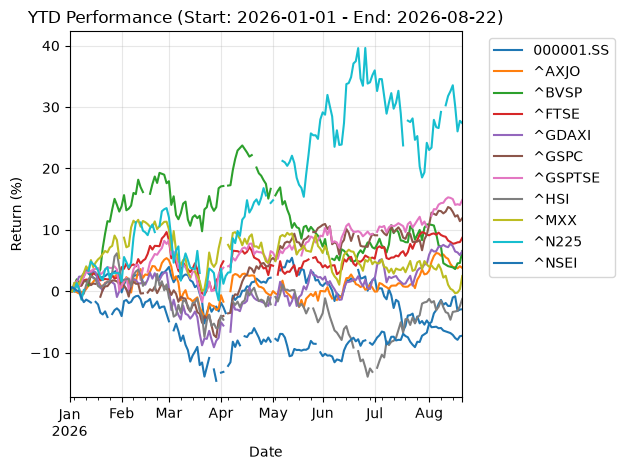

In [18]:
#visualize year-to-date returns
plt.figure(figsize=(12, 6))
ytd_performance.plot(title=f"YTD Performance (Start: {DATE_START} - End: {DATE_END})")
plt.ylabel("Return (%)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
ytd_performance.iloc[-1].index.to_list()

['000001.SS',
 '^AXJO',
 '^BVSP',
 '^FTSE',
 '^GDAXI',
 '^GSPC',
 '^GSPTSE',
 '^HSI',
 '^MXX',
 '^N225',
 '^NSEI']

In [20]:
ytd_performance.iloc[-1].values

array([-2.93815211,  3.79363177,  6.53610649,  8.69753127,  6.50881692,
       11.89623745, 14.85663   , -1.24916047,  2.4755015 , 27.36405978,
       -7.24589181])

In [21]:
#df of ytd returns
ytd_df_last = pd.DataFrame(data={"ticker": ytd_performance.iloc[-1].index.to_list(), "ytd": ytd_performance.iloc[-1].values})
ytd_df_last

,ticker,ytd
0,000001.SS,-2.938152
1,^AXJO,3.793632
2,^BVSP,6.536106
3,^FTSE,8.697531
4,^GDAXI,6.508817
5,^GSPC,11.896237
6,^GSPTSE,14.856630
7,^HSI,-1.249160
8,^MXX,2.475501
9,^N225,27.364060


In [22]:
#use ^GSPC as reference
sp_ticker = ytd_df_last["ticker"] == "^GSPC"
sp_row = ytd_df_last[sp_ticker]
sp_row

,ticker,ytd
5,^GSPC,11.896237


In [23]:
#identify indexes above reference
threshold = sp_row.get("ytd").item()
print(threshold)
higher_ytd_mask = ytd_df_last["ytd"] > threshold
ytd_df_last[higher_ytd_mask]

11.896237452163927


,ticker,ytd
6,^GSPTSE,14.85663
9,^N225,27.36406


How many of these indexes have better returns than the S&P 500 over 3, 5, and 10 year periods? Do you see the same trend?

In [24]:
#get index data
data = yfn.download(
    TICKERS,
    period="max"
)["Close"]

data.head()

[*********************100%***********************]  11 of 11 completed


Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
1927-12-30,NaN,NaN,NaN,NaN,NaN,17.660000,NaN,NaN,NaN,NaN,NaN
1928-01-03,NaN,NaN,NaN,NaN,NaN,17.760000,NaN,NaN,NaN,NaN,NaN
1928-01-04,NaN,NaN,NaN,NaN,NaN,17.719999,NaN,NaN,NaN,NaN,NaN
1928-01-05,NaN,NaN,NaN,NaN,NaN,17.549999,NaN,NaN,NaN,NaN,NaN
1928-01-06,NaN,NaN,NaN,NaN,NaN,17.660000,NaN,NaN,NaN,NaN,NaN


In [25]:
#figuring out date periods with custom years
start_date = pd.to_datetime(DATE_END) - pd.DateOffset(years=3)
end_date = pd.to_datetime(DATE_END)
print(start_date, end_date)

2023-08-22 00:00:00 2026-08-22 00:00:00


In [26]:
#if desired date has no data, use previous date
start_idx = data.index.get_indexer([start_date], method="ffill")
start_idx

array([24516])

In [27]:
#inspect prices of each index (some may be missing)
data.iloc[start_idx]

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2023-08-22,3120.330078,7121.600098,116156.0,7270.799805,15705.620117,4387.549805,19691.199219,17791.009766,53127.929688,31856.710938,19396.449219


In [28]:
end_idx = data.index.get_indexer([end_date], method="ffill")
end_idx

array([25300])

In [29]:
data.iloc[end_idx]

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2026-08-21,3905.202881,9058.900391,171032.0,10816.599609,26136.560547,7674.370117,36620.199219,26009.460938,65729.179688,66016.359375,24252.0


In [30]:
#as it is a df i can apply same valid index logic in case of missing values
type(data.iloc[[start_idx[0], end_idx[0]]])

pandas.DataFrame

In [31]:
def get_simple_return(df: pd.DataFrame, years: int):
    #get an index for start/end dates
    start_date = pd.to_datetime(DATE_END) - pd.DateOffset(years=years)
    end_date = pd.to_datetime(DATE_END)
    #use index within desired range, go to prev index if no exact match
    start_idx = df.index.get_indexer([start_date], method="ffill")[0]
    end_idx = df.index.get_indexer([end_date], method="ffill")[0]
    #use data in range start/end indexes
    df_range = df.iloc[[start_idx, end_idx]].copy()
    #use only diagonal values (value of first valid index)
    start_values = df_range.apply(lambda column : column[column.first_valid_index()])
    end_values = df_range.apply(lambda column : column[column.last_valid_index()])
    #calculate period returns
    simple_return = ((end_values - start_values) / start_values) * 100
    return simple_return

In [32]:
returns_3y = get_simple_return(data, 3)
returns_3y

Ticker
000001.SS     25.153518
^AXJO         27.203160
^BVSP         47.243362
^FTSE         48.767672
^GDAXI        66.415336
^GSPC         74.912433
^GSPTSE       85.972417
^HSI          46.194405
^MXX          23.718692
^N225        107.229050
^NSEI         25.033194
dtype: float64

In [33]:
returns_5y = get_simple_return(data, 5)
returns_5y

Ticker
000001.SS     13.942875
^AXJO         21.418334
^BVSP         44.877301
^FTSE         52.606551
^GDAXI        65.337135
^GSPC         72.781189
^GSPTSE       80.049163
^HSI           4.667015
^MXX          27.842164
^N225        144.385105
^NSEI         47.424090
dtype: float64

In [34]:
returns_10y = get_simple_return(data, 10)
returns_10y

Ticker
000001.SS     26.594808
^AXJO         64.256319
^BVSP        196.000415
^FTSE         58.403743
^GDAXI       149.053648
^GSPC        251.609541
^GSPTSE      148.302835
^HSI          13.094889
^MXX          36.103684
^N225        297.732292
^NSEI        181.047367
dtype: float64

In [35]:
#df from 3,5,10 yrs
results = pd.DataFrame({
    "ticker": returns_3y.index,
    "3yr_ret": returns_3y.values,
    "5yr_ret": returns_5y.values,
    "10yr_ret": returns_10y.values
})

results

,ticker,3yr_ret,5yr_ret,10yr_ret
0,000001.SS,25.153518,13.942875,26.594808
1,^AXJO,27.203160,21.418334,64.256319
2,^BVSP,47.243362,44.877301,196.000415
3,^FTSE,48.767672,52.606551,58.403743
4,^GDAXI,66.415336,65.337135,149.053648
5,^GSPC,74.912433,72.781189,251.609541
6,^GSPTSE,85.972417,80.049163,148.302835
7,^HSI,46.194405,4.667015,13.094889
8,^MXX,23.718692,27.842164,36.103684
9,^N225,107.229050,144.385105,297.732292


In [36]:
#use ^GSPC as reference
sp_ticker = results["ticker"] == "^GSPC"
sp_row = results[sp_ticker]
sp_row

,ticker,3yr_ret,5yr_ret,10yr_ret
5,^GSPC,74.912433,72.781189,251.609541


In [37]:
#identify values in 3yr_ret above threshold, i kept remaining years
threshold_3yr = sp_row.get("3yr_ret").item()
print(threshold_3yr)
higher_3yr_ret_mask = results["3yr_ret"] > threshold_3yr
results[higher_3yr_ret_mask]

74.9124331076192


,ticker,3yr_ret,5yr_ret,10yr_ret
6,^GSPTSE,85.972417,80.049163,148.302835
9,^N225,107.229050,144.385105,297.732292


In [38]:
threshold_5yr = sp_row.get("5yr_ret").item()
print(threshold_5yr)
higher_5yr_ret_mask = results["5yr_ret"] > threshold_5yr
results[higher_5yr_ret_mask]

72.78118933132818


,ticker,3yr_ret,5yr_ret,10yr_ret
6,^GSPTSE,85.972417,80.049163,148.302835
9,^N225,107.229050,144.385105,297.732292


In [39]:
threshold_10yr = sp_row.get("10yr_ret").item()
print(threshold_10yr)
higher_10yr_ret_mask = results["10yr_ret"] > threshold_10yr
results[higher_10yr_ret_mask]

251.6095414219964


,ticker,3yr_ret,5yr_ret,10yr_ret
9,^N225,107.22905,144.385105,297.732292


Question 3. [Index] S&P 500 Market Corrections Analysis
Calculate the median drawdown (in %) of significant market corrections in the S&P 500 index.

For this task, define a correction as an event when a stock index goes down by at least 5% from the most recent all-time high.

Steps:

Download S&P 500 historical data (period from 1950 to present) using yfinance (daily stats) \
Identify all-time high closing price points (where price exceeds all previous days' prices) \
For each pair of consecutive all-time highs, find the minimum price in between \
Calculate drawdown percentages: (high - low) / high × 100 \
Filter for corrections with at least 5% drawdown \
Calculate the duration in days for each correction period \
Determine the 25th, 50th (median), and 75th percentiles for correction durations and drawdowns

In [40]:
df = yfn.Ticker("^GSPC").history(period="max")
df = df[["Close"]].dropna()
df.index = pd.to_datetime(df.index).normalize()
prices = df["Close"]

#identify aths
running_max = prices.cummax()

#find idxs where new ath is set
#running_max strictly increases compared to previous value
new_ath_mask = running_max > running_max.shift(1, fill_value=0)
ath_indices = prices.index[new_ath_mask]

#episode runs from one ATH to the next ATH
corrections = []
for i in range(len(ath_indices) - 1):
    peak_date = ath_indices[i]
    next_ath_date = ath_indices[i + 1]
    
    #episode is from peak_date (inclusive) to next_ath_date (exclusive)
    episode = prices.loc[peak_date:next_ath_date].iloc[:-1]
    
    if len(episode) == 0:
        continue
    
    peak_price = prices.loc[peak_date]
    trough_date = episode.idxmin()
    trough_price = episode.min()
    
    drawdown_pct = (peak_price - trough_price) / peak_price * 100
    duration_days = (trough_date - peak_date).days
    
    #corrections with ge 5% drawdown
    if drawdown_pct >= 5.0:
        corrections.append({
            "peak_date": peak_date,
            "trough_date": trough_date,
            "drawdown_pct": round(drawdown_pct, 1),
            "duration_days": duration_days,
        })

corr_df = pd.DataFrame(corrections)

#summary
print(f"Total corrections (>=5%): {len(corr_df)}\n")

print("Drawdown %")
print(f"50th percentile (median): {corr_df['drawdown_pct'].quantile(0.50):.1f}%")
print(f"25th percentile: {corr_df['drawdown_pct'].quantile(0.25):.1f}%")
print(f"75th percentile: {corr_df['drawdown_pct'].quantile(0.75):.1f}%")

print("\nDuration (days)")
print(f"25th percentile: {corr_df['duration_days'].quantile(0.25):.0f} days")
print(f"50th percentile (median): {corr_df['duration_days'].quantile(0.50):.0f} days")
print(f"75th percentile: {corr_df['duration_days'].quantile(0.75):.0f} days")

#top 10 largest corrections
print("\nTop 10 largest corrections")
#printing to compare against reference output
top10 = corr_df.sort_values("drawdown_pct", ascending=False).head(11)[1:11]
for _, row in top10.iterrows():
    print(
        f"{row['peak_date'].strftime('%Y-%m-%d')} to {row['trough_date'].strftime('%Y-%m-%d')}: "
        f"{row['drawdown_pct']}% drawdown over {row['duration_days']} days"
    )

Total corrections (>=5%): 73

Drawdown %
50th percentile (median): 8.2%
25th percentile: 6.2%
75th percentile: 14.0%

Duration (days)
25th percentile: 20 days
50th percentile (median): 34 days
75th percentile: 87 days

Top 10 largest corrections
2007-10-09 to 2009-03-09: 56.8% drawdown over 517 days
2000-03-24 to 2002-10-09: 49.1% drawdown over 928 days
1973-01-11 to 1974-10-03: 48.2% drawdown over 629 days
1968-11-29 to 1970-05-26: 36.1% drawdown over 542 days
2020-02-19 to 2020-03-23: 33.9% drawdown over 32 days
1987-08-25 to 1987-12-04: 33.5% drawdown over 101 days
1961-12-12 to 1962-06-26: 28.0% drawdown over 195 days
1980-11-28 to 1982-08-12: 27.1% drawdown over 621 days
2022-01-03 to 2022-10-12: 25.4% drawdown over 281 days
1966-02-09 to 1966-10-07: 22.2% drawdown over 239 days


Question 4. [Stocks] Earnings Surprise Analysis for Amazon (AMZN)
Calculate the median 2-day percentage change in stock prices following positive earnings surprise days.

Steps:

Load earnings data for the last few years using the yfinance method get_earnings_dates():
import yfinance as yf

ticker = 'AMZN' \
ticker_obj = yf.Ticker(ticker) \
result = ticker_obj.get_earnings_dates() \
You should have 25 entries starting from 2020-10-29. Note: the 1 future earnings date entry will not have Reported EPS and Surprise % filled in.

Download complete historical price data using yfinance \
Calculate 2-day percentage changes for all historical dates: for each sequence of 3 consecutive trading days (Day 1, Day 2, Day 3), compute the return as Close_Day3 / Close_Day1 - 1. (Assume Day 2 may correspond to the earnings announcement.) \
Filter for positive earnings surprises and calculate the median 2-day return. Then calculate the correlation between the 2-day stock return and the earnings surprise magnitude.

In [41]:
ticker = yfn.Ticker("AMZN")
earnings = ticker.get_earnings_dates()
prices = ticker.history(period="max")["Close"]
#normalize both datetime indexes
prices.index = prices.index.tz_localize(None).normalize()
earnings.index = pd.to_datetime(earnings.index).tz_localize(None).normalize()
#keep only earnings dates that fall on actual trading days
valid = earnings.index.intersection(prices.index)
earnings = earnings.loc[valid]
#shift on the dull daily series (1 and 3 trading days ahead)
price_full = pd.DataFrame({
    #next trading day"s close
    "day1": prices.shift(1),
    #close 3 trading days ahead
    "day3": prices.shift(-1)
})

#look up values at the earnings dates
price_at = price_full.reindex(earnings.index)
#this calculates returns but as decimal
ret_2day = price_at["day3"] / price_at["day1"] - 1

#filter positive surprises, then median
pos = ret_2day[earnings["Surprise(%)"] > 0]
print(f"Median 2-day return (positive surprise): {pos.median()*100:.2f}")

#correlation between 2-day return and surprise magnitude
correlation = ret_2day.corr(earnings["Surprise(%)"])
print(f"Correlation (return vs surprise): {correlation:.2f}")

#correlation between 2-day return and surprise magnitude > 0
correlation = pos.corr(earnings[earnings["Surprise(%)"] > 0]["Surprise(%)"])
print(f"Correlation (return vs surprise) > 0: {correlation:.2f}")

Median 2-day return (positive surprise): 0.35
Correlation (return vs surprise): 0.22
Correlation (return vs surprise) > 0: 0.33
